# 1. Setup

## 1.1 Libraries, Imports, API keys

In [16]:
!pip install pandas
!pip install langchain_community
!pip install langchain-tavily
!pip install openai
!pip install seaborn
!pip install python-dotenv
!pip install chromadb

In [17]:
import pandas as pd
import numpy as np
import json
import re
from typing import List, Dict, Any, Tuple, Literal, TypedDict
from sentence_transformers import SentenceTransformer
from openai import OpenAI
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
from dotenv import load_dotenv
from google.colab import userdata
from langchain_tavily import TavilySearch
import openai
import chromadb
import os

In [25]:
os.environ["OPENAI_API_KEY"] = userdata.get("OPEN_AI_API")
os.environ["TAVILY_API_KEY"] = userdata.get("TAVILY_API")


## Datasets

In [4]:
df_qa = pd.read_csv("./train.csv")
df_qa = df_qa.sample(500, random_state=0).reset_index(drop=True)
df_qa

,qtype,Question,Answer
0,frequency,How many people are affected by X-linked chond...,The prevalence of X-linked chondrodysplasia pu...
1,treatment,What are the treatments for Kawasaki disease ?,These resources address the diagnosis or manag...
2,genetic changes,What are the genetic changes related to Ellis-...,Ellis-van Creveld syndrome can be caused by mu...
3,symptoms,What are the symptoms of Renal dysplasia-limb ...,What are the signs and symptoms of Renal dyspl...
4,information,What is (are) Fraser syndrome ?,Fraser syndrome is a rare disorder that affect...
...,...,...,...
495,inheritance,Is Tubular aggregate myopathy inherited ?,Is tubular aggregate myopathy genetic? It is e...
496,information,Do you have information about Iron,Summary : Iron is a mineral that our bodies ne...
497,research,what research (or clinical trials) is being do...,The NINDS supports research on disorders that ...
498,treatment,What are the treatments for Chronic Eosinophil...,Treatment of chronic eosinophilic leukemia may...


In [5]:
df_qa['combined_text'] = (
    "Question: " + df_qa['Question'].astype(str) + '. ' +
    "Answer: " + df_qa['Answer'].astype(str) + '. ' +
    "Type: " + df_qa['qtype'].astype(str) + '. '
)
df_qa.head()

,qtype,Question,Answer,combined_text
0,frequency,How many people are affected by X-linked chond...,The prevalence of X-linked chondrodysplasia pu...,Question: How many people are affected by X-li...
1,treatment,What are the treatments for Kawasaki disease ?,These resources address the diagnosis or manag...,Question: What are the treatments for Kawasaki...
2,genetic changes,What are the genetic changes related to Ellis-...,Ellis-van Creveld syndrome can be caused by mu...,Question: What are the genetic changes related...
3,symptoms,What are the symptoms of Renal dysplasia-limb ...,What are the signs and symptoms of Renal dyspl...,Question: What are the symptoms of Renal dyspl...
4,information,What is (are) Fraser syndrome ?,Fraser syndrome is a rare disorder that affect...,Question: What is (are) Fraser syndrome ?. Ans...


In [6]:
df_md = pd.read_csv("./medical_device_manuals_dataset.csv")
df_md = df_md.sample(500, random_state=0).reset_index(drop=True)
df_md

,Device_Name,Model_Number,Manufacturer,Manual_Version,Publication_Date,Device_Class,Regulatory_Approval_ID,Patient_Population,Indications_for_Use,Contraindications,Sterilization_Method,Number_of_Warnings,Number_of_Cautions,Device_Lifetime_Years,Device_Weight_kg,Max_Operating_Temperature_C
0,Electrosurgical Unit,Model 1606,Zimmer Biomet,2023-04-Z,2018-04-28,Class IIb,MDR-847127,All,Used for thermal therapy guidance in oncology ...,Contraindicated in presence of radio frequenci...,Hydrogen Peroxide Plasma,10,15,15.0,6.71,27.0
1,Dialysis Machine,X-6538,3M Healthcare,v2.8,2018-04-03,Class I,MDR-416480,Adult (>65),Used for post-operative chemotherapy managemen...,NaN,Gamma Irradiation,8,11,11.0,NaN,17.0
2,Ventilator,SON230,Sonova,Version 13,2022-02-24,Class III,BLA670706,Adult (>65),Indicated for real-time temperature assessment...,Do not use during general anesthesia administr...,Pre-Sterilized,18,28,11.0,149.42,25.0
3,Dialysis Machine,Max787,Boston Scientific,v4.7,2016-05-08,Class II,BLA131698,Neonatal,Intended for sterilization guidance during min...,"Not recommended during pregnancy, lactation, o...",NaN,10,15,15.0,20.96,20.0
4,Electrosurgical Unit,Plus691,Abbott,2020-03-Q,2015-01-30,Class III,H127393,Pediatric,Intended for life support evaluation in rehabi...,Contraindicated in patients with severe diabet...,Single-Use Sterile,13,17,8.0,7.75,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Catheter,BAX938,Baxter International,v5.0,2018-04-27,Class I,NaN,Neonatal,Used for long-term electrotherapy delivery in ...,Contraindicated in presence of gadolinium agen...,Ethylene Oxide (EtO),4,12,5.0,18.76,12.0
496,Defibrillator,STE899,Steris,Rev. 10.3,2019-02-06,Class II,PMDA-564910,All,Indicated for continuous respiratory rate moni...,Do not use in combination with conductive gels...,Steam Sterilization,19,26,5.0,1.08,15.0
497,Anesthesia Machine,BOS219,Boston Scientific,Rev. 7.3,2024-03-31,Class IIa,IVDR-776258,Adult and Pediatric,Indicated for intracranial pressure surveillan...,Do not use if structural defects is present or...,Steam Sterilization,22,19,12.0,86.83,18.0
498,Anesthesia Machine,Model 6689,Baxter International,2021-02-O,2015-04-29,Class II,P208447,Pediatric,Indicated for electrolyte balance surveillance...,Avoid use if patient has severe diabetes or is...,Single-Use Sterile,15,12,14.0,65.03,7.0


In [7]:
df_md['combined_text'] = (
    "Device Name: " + df_md['Device_Name'].astype(str) + ". " +
    "Model: " + df_md['Model_Number'].astype(str) + ". " +
    "Manufacturer: " + df_md['Manufacturer'].astype(str) + ". " +
    "Indications: " + df_md['Indications_for_Use'].astype(str) + ". " +
    "Contraindications: " + df_md['Contraindications'].fillna('None').astype(str)
)
df_md.head()

,Device_Name,Model_Number,Manufacturer,Manual_Version,Publication_Date,Device_Class,Regulatory_Approval_ID,Patient_Population,Indications_for_Use,Contraindications,Sterilization_Method,Number_of_Warnings,Number_of_Cautions,Device_Lifetime_Years,Device_Weight_kg,Max_Operating_Temperature_C,combined_text
0,Electrosurgical Unit,Model 1606,Zimmer Biomet,2023-04-Z,2018-04-28,Class IIb,MDR-847127,All,Used for thermal therapy guidance in oncology ...,Contraindicated in presence of radio frequenci...,Hydrogen Peroxide Plasma,10,15,15.0,6.71,27.0,Device Name: Electrosurgical Unit. Model: Mode...
1,Dialysis Machine,X-6538,3M Healthcare,v2.8,2018-04-03,Class I,MDR-416480,Adult (>65),Used for post-operative chemotherapy managemen...,NaN,Gamma Irradiation,8,11,11.0,NaN,17.0,Device Name: Dialysis Machine. Model: X-6538. ...
2,Ventilator,SON230,Sonova,Version 13,2022-02-24,Class III,BLA670706,Adult (>65),Indicated for real-time temperature assessment...,Do not use during general anesthesia administr...,Pre-Sterilized,18,28,11.0,149.42,25.0,Device Name: Ventilator. Model: SON230. Manufa...
3,Dialysis Machine,Max787,Boston Scientific,v4.7,2016-05-08,Class II,BLA131698,Neonatal,Intended for sterilization guidance during min...,"Not recommended during pregnancy, lactation, o...",NaN,10,15,15.0,20.96,20.0,Device Name: Dialysis Machine. Model: Max787. ...
4,Electrosurgical Unit,Plus691,Abbott,2020-03-Q,2015-01-30,Class III,H127393,Pediatric,Intended for life support evaluation in rehabi...,Contraindicated in patients with severe diabet...,Single-Use Sterile,13,17,8.0,7.75,31.0,Device Name: Electrosurgical Unit. Model: Plus...


## 1.3 Chroma DB

In [10]:
client = chromadb.PersistentClient(path="./chroma_db")

In [9]:
collection1 = client.get_or_create_collection(name="medical_qa")

In [11]:
collection1.add(
    documents=df_qa['combined_text'].tolist(),
    metadatas=df_qa.to_dict(orient='records'),
    ids=df_qa.index.astype(str).tolist()
)


/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:02<00:00, 27.8MiB/s]


In [12]:
collection2 = client.get_or_create_collection(name="medical_device_manuals")

In [13]:
collection2.add(
    documents=df_qa['combined_text'].tolist(),
    metadatas=df_qa.to_dict(orient='records'),
    ids=df_qa.index.astype(str).tolist()
)


In [14]:
# test
query = "what are the devices relevant to surgery"

results = collection2.query(query_texts=[query], n_results=2)
print(results)

{'ids': [['195', '213']], 'embeddings': None, 'documents': [["Question: what research (or clinical trials) is being done for Penile Cancer ?. Answer: New types of treatment are being tested in clinical trials.\n                    This summary section describes treatments that are being studied in clinical trials. It may not mention every new treatment being studied. Information about clinical trials is available from the NCI website.     Radiosensitizers     Radiosensitizers are drugs that make tumor cells more sensitive to radiation therapy. Combining radiation therapy with radiosensitizers helps kill more tumor cells.       Sentinel lymph node biopsy followed by surgery     Sentinel lymph node biopsy is the removal of the sentinel lymph node during surgery. The sentinel lymph node is the first lymph node to receive lymphatic drainage from a tumor. It is the first lymph node the cancer is likely to spread to from the tumor. A radioactive substance and/or blue dye is injected near the

## 1.4 Web Search

In [27]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily_search = TavilySearchResults(topic="general", max_results=3)

query = 'What is speciality of dunkirk'

result = tavily_search.invoke({"query": query})

print(type(result))
print(result[0])

<class 'list'>
{'title': '[PDF] Dunkirk Specialty Steel (USAP) - Universal Stainless & Alloy Products', 'url': 'https://www.univstainless.com/admin/uploads/quality-policy-manual-as-9100-rev-13-dnk.pdf', 'content': 'provision where the resulting output cannot be verified by subsequent monitoring or measurement. This includes any processes where deficiencies become apparent only after the product is in use or the service has been delivered. Dunkirk Specialty Steel Quality Manual Rev: 13 Date: 12/19/2017 ________________________________________________________________________________________________________ ________________________________________________________________ Page 23 of 31 Rev 13 Validation of these “special processes” demonstrates the ability of these processes to achieve planned results. DSS has established arrangements for these processes including, as applicable a) defined criteria for review and approval of the processes, b) approval of equipment and qualification of pers

## 1.5 OpenAI API - Models

In [28]:
from langchain_core.tools import tool

from openai import OpenAI

def get_llm_response(prompt: str) -> str:
    """Function to get response from LLM"""
    from openai import OpenAI
    client_llm = OpenAI(api_key=openai_api_key)
    response = client_llm.chat.completions.create(
        model="gpt-5-nano",
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

prompt = "What is speciality of dunkirk"
response = get_llm_response(prompt)

In [29]:
response

'Do you mean Dunkirk (Dunkerque) in France, the World War II evacuation, or the film about it? Here are quick notes on the main possibilities:\n\n- Dunkirk, France (city): A major port on the North Sea. It’s known for its large commercial and naval port, fishing, its beaches, and the historical significance of the Dunkirk evacuation in World War II.\n\n- Dunkirk evacuation (Operation Dynamo): Famous for rescuing hundreds of thousands of Allied soldiers from the beaches of Dunkirk in 1940, a turning point early in World War II.\n\n- Dunkirk (film, 2017): Noted for its immersive, tense portrayal of the evacuation, its minimal dialogue, interwoven timelines, practical effects, and Hans Zimmer’s score.\n\nWhich one are you asking about? If you meant something else, tell me and I’ll tailor the answer.'

# 2. Pipeline

In [32]:
from langgraph.graph import StateGraph, MessagesState, START, END

def retrieve_context_q_n_a(state):
    """Retrieve top documents from ChromaDB Collection 1 (Medical Q&A Data) based on query."""
    print("---RETRIEVING CONTEXT---")
    query = state["query"]
    results = collection1.query(query_texts=[query], n_results=3)
    context = "\n".join(results["documents"][0])
    state["context"] = context
    state["source"] = "Medical Q&A Collection"
    print(context)

    return state

def retrieve_context_medical_device(state):
    """Retrieve top documents from ChromaDB Collection 2 (Medical Device Manuals Data) based on query."""
    query = state['query']
    results = collection2.query(query_texts=[query], n_results=3)
    context = "\n".join(results["documents"][0])
    state["context"] = context
    state["source"] = "Medical Device Manual"
    print(context)

    return state

def tavily_web_search(state):
    """Perform web search using the Tavily Search API."""
    print("--- Performing Tavily Web Search ---")
    tavily_search = TavilySearch(topic="general", max_results=1)
    query = state['query']
    result_ = tavily_search.invoke({"query": query})
    state["context"] = result_['results'][0]['content']

    return state


def router(state: GraphState) -> Literal[
    "Retrieve_QnA", "Retrieve_Device", "Web_Search"
]:
    """Agentic router: decides which retrieval method to use."""
    query = state["query"]

    # A lightweight decision LLM — you can replace this with GPT-4o-mini, etc.
    decision_prompt = f"""
    You are a routing agent. Based on the user query, decide where to look for information.

    Options:
    - Retrieve_QnA: if it's about general medical knowledge, symptoms, or treatment.
    - Retrieve_Device: if it's about medical devices, manuals, or instructions.
    - Web_Search: if it's about recent news, brand names, or external data.

    Query: "{query}"

    Respond ONLY with one of: Retrieve_QnA, Retrieve_Device, Web_Search
    """

    router_decision = get_llm_response(decision_prompt).strip()
    print(f"---ROUTER DECISION: {router_decision}---")

    print(router_decision)

    state["source"] = router_decision

    return state

def route_decision(state: GraphState) -> str:
    return state["source"]


def check_context_relevance(state: GraphState):
    """Determine whether the retrieved context is relevant or not."""
    print("---CONTEXT RELEVANCE CHECKER---")
    query = state["query"]
    context = state["context"]

    relevance_prompt = f"""
    Check the context below to see if the context is relevant to the user query or not.
    ####
    Context:
    {context}
    ####
    User Query: {query}

    Options:
    - Yes: if the context is relevant.
    - No: if the context is not relevant.

    Please answer with only 'Yes' or 'No'.
    """
    relevance_decision_value = get_llm_response(relevance_prompt).strip()
    print(f"---RELEVANCE DECISION: {relevance_decision_value}---")
    state["is_relevant"] = relevance_decision_value

    return state


def relevance_decision(state: GraphState) -> str:
    iteration_count = state.get("iteration_count", 0)
    iteration_count += 1
    state["iteration_count"] = iteration_count
    ## Limiting to max 3 iterations
    if iteration_count >= 3:
        print("---MAX ITERATIONS REACHED, FORCING 'Yes'---")
        state["is_relevant"] = "Yes"
    return state["is_relevant"]



def build_prompt(state):
    """Construct the RAG-style prompt."""
    print("---AUGMENT (BUILDING GENERATIVE PROMPT)---")
    query = state["query"]
    context = state["context"]

    prompt = f"""
    Answer the following question using the context below.
    Context:
    {context}
    Question: {query}
    please limit your answer in 50 words.
    """

    state["prompt"] = prompt
    print(prompt)
    return state

def call_llm(state):
    """Call your existing LLM function."""
    print("---GENERATE (CALLING LLM)---")
    prompt = state["prompt"]
    answer = get_llm_response(prompt)
    state["response"] = answer
    return state

In [33]:
class GraphState(TypedDict):
    query: str
    context: str
    prompt: str
    response: str
    source: str
    is_relevant: str
    iteration_count: str

workflow = StateGraph(GraphState)

workflow.add_node("Router", router)
workflow.add_node("Retrieve_QnA", retrieve_context_q_n_a)
workflow.add_node("Retrieve_Device", retrieve_context_medical_device)
workflow.add_node("Web_Search", tavily_web_search)
workflow.add_node("Relevance_Checker", check_context_relevance)
workflow.add_node("Augment", build_prompt)
workflow.add_node("Generate", call_llm)

workflow.add_edge(START, "Router")
workflow.add_conditional_edges(
    "Router",
    route_decision,
    {
        "Retrieve_QnA": "Retrieve_QnA",
        "Retrieve_Device": "Retrieve_Device",
        "Web_Search": "Web_Search",
    }
)
workflow.add_edge("Retrieve_QnA", "Relevance_Checker")
workflow.add_edge("Retrieve_Device", "Relevance_Checker")
workflow.add_edge("Web_Search", "Relevance_Checker")
workflow.add_conditional_edges(
    "Relevance_Checker",
    relevance_decision,
    {
        "Yes": "Augment",
        "No": "Web_Search",
    }
)
workflow.add_edge("Augment", "Generate")
workflow.add_edge("Generate", END)

agentic_rag = workflow.compile()

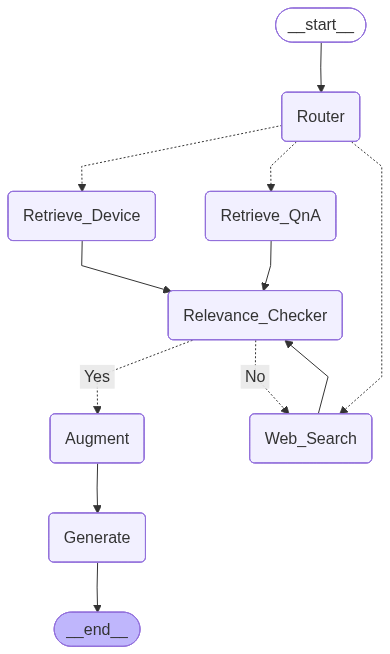

In [34]:
# Visualiza State Graph

from IPython.display import Image, display
display(Image(agentic_rag.get_graph().draw_mermaid_png()))

# 3. Test the Agentic RAG Pipeline

In [35]:
input_state = {"query": "what is the treatment for down's symdrome"}

from pprint import pprint
for step in agentic_rag.stream(input_state):
    for key, value in step.items():
        pprint(f"Finished running {key}:")
pprint(value["response"])

---ROUTER DECISION: Retrieve_QnA---
Retrieve_QnA
'Finished running Router:'
---RETRIEVING CONTEXT---
Question: What are the treatments for Antisynthetase syndrome ?. Answer: What treatment is available for antisynthetase syndrome? Corticosteroids are typically the first-line of treatment and may be required for several months or years. These medications are often given orally; however, in severe cases, intravenous methylprednisolone may be prescribe initially. Immunosuppressive medications may also be recommended, especially in people with severe muscle weakness or symptomatic interstitial lung disease. Physical therapy is often necessary to improve weakness, reduce further muscle wasting from disuse, and prevent muscle contractures.. Type: treatment. 
Question: What are the treatments for Orthostatic Hypotension ?. Answer: When orthostatic hypotension is caused by hypovolemia due to medications, the disorder may be reversed by adjusting the dosage or by discontinuing the medication. W

In [36]:
input_state = {"query": "what was the company created the first vaccine for COVID-19"}

from pprint import pprint
for step in agentic_rag.stream(input_state):
    for key, value in step.items():
        pprint(f"Finished running {key}:")
pprint(value["response"])

---ROUTER DECISION: Web_Search---
Web_Search
'Finished running Router:'
--- Performing Tavily Web Search ---
'Finished running Web_Search:'
---CONTEXT RELEVANCE CHECKER---
---RELEVANCE DECISION: Yes---
'Finished running Relevance_Checker:'
---AUGMENT (BUILDING GENERATIVE PROMPT)---

    Answer the following question using the context below.
    Context:
    ... vaccines against COVID-19, which had paralyzed the entire world for more than a year. Pfizer and BioNTech codeveloped the first COVID-19 vaccine that was
    Question: what was the company created the first vaccine for COVID-19
    please limit your answer in 50 words.
    
'Finished running Augment:'
---GENERATE (CALLING LLM)---
'Finished running Generate:'
'Pfizer and BioNTech co-developed the first COVID-19 vaccine.'
